In [1]:
print()
from utils import get_gradcam,preprocess_image
import os
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
TEST_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/'
class_mapping={'COVID':0,'Normal':1,'Viral Pneumonia':2}

In [3]:
model=load_model('C:\\Users\\PratushPc\\OneDrive\\Desktop\\ExCV\\models\\best_model.keras')

In [4]:
covid_heatmaps = []
normal_heatmaps = []
viral_heatmaps = []

for class_ in os.listdir(TEST_PATH)[1:]:

    class_path = os.path.join(TEST_PATH, class_)

    count = 0

    for img_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            img_name
        )

        img,processed_img = preprocess_image(img_path)

        pred = model.predict(
            processed_img,
            verbose=0
        )[0]

        pred_idx = np.argmax(pred)

        actual_idx = class_mapping[class_]

        if pred_idx != actual_idx:
            continue

        heatmap = get_gradcam(
            model,
            img_path,
            pred_idx
        )


        heatmap=(heatmap-heatmap.min())/(heatmap.max()-heatmap.min())
        
        if np.max(pred)>0.99:
            if class_ == "COVID":
                covid_heatmaps.append(heatmap)

            elif class_ == "Normal":
                normal_heatmaps.append(heatmap)

            else:
                viral_heatmaps.append(heatmap)

        count += 1

        if count == 30:
            break

In [5]:
covid_avg = np.mean(
    covid_heatmaps,
    axis=0
)

normal_avg = np.mean(
    normal_heatmaps,
    axis=0
)

viral_avg = np.mean(
    viral_heatmaps,
    axis=0
)

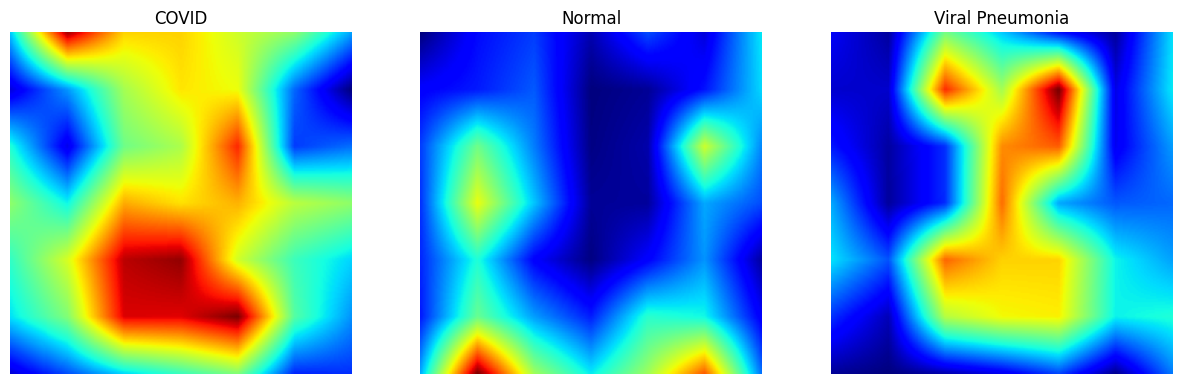

In [6]:
fig,axes = plt.subplots(
    1,3,
    figsize=(15,5)
)

for ax,hm,title in zip(
    axes,
    [covid_avg,normal_avg,viral_avg],
    ["COVID","Normal","Viral Pneumonia"]
):

    ax.imshow(hm,cmap="jet")

    ax.set_title(title)

    ax.axis("off")

plt.show()

In [8]:
in_covid_heatmaps = []
in_normal_heatmaps = []
in_viral_heatmaps = []

for class_ in os.listdir(TEST_PATH)[1:]:

    class_path = os.path.join(TEST_PATH, class_)

    count = 0

    for img_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            img_name
        )

        img,processed_img = preprocess_image(img_path)

        pred = model.predict(
            processed_img,
            verbose=0
        )[0]

        pred_idx = np.argmax(pred)

        actual_idx = class_mapping[class_]

        if pred_idx == actual_idx:
            continue

        heatmap = get_gradcam(
            model,
            img_path,
            pred_idx
        )

        heatmap=(heatmap-heatmap.min())/(heatmap.max()-heatmap.min())
        
       
        if class_ == "COVID":
            in_covid_heatmaps.append(heatmap)

        elif class_ == "Normal":
            in_normal_heatmaps.append(heatmap)

        else:
            in_viral_heatmaps.append(heatmap)

        count += 1

        if count == 30:
            break

In [9]:
in_covid_avg = np.mean(
    in_covid_heatmaps,
    axis=0
)

in_normal_avg = np.mean(
    in_normal_heatmaps,
    axis=0
)

in_viral_avg = np.mean(
    in_viral_heatmaps,
    axis=0
)

c:\Users\PratushPc\miniconda3\envs\py310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\PratushPc\miniconda3\envs\py310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
in_covid_avg
in_normal_avg

nan

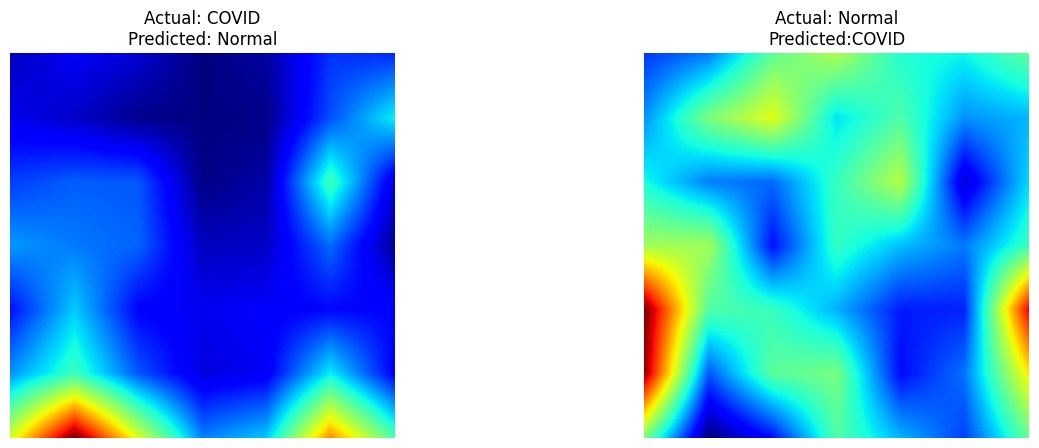

In [17]:
fig,axes = plt.subplots(
    1,2,
    figsize=(15,5)
)

for ax,hm,title in zip(
    axes,
    [in_covid_avg,in_normal_avg],
    ["Actual: COVID\nPredicted: Normal","Actual: Normal\nPredicted:COVID"]
):

    ax.imshow(hm,cmap="jet")

    ax.set_title(title)

    ax.axis("off")

plt.show()